In [77]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import HTML, clear_output, display
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from sktime.split import ExpandingWindowSplitter
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Visualization setup
from pylab import rcParams
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

sys.path.append('/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional')

%load_ext autoreload
%autoreload 2

from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error, visualize_ts
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


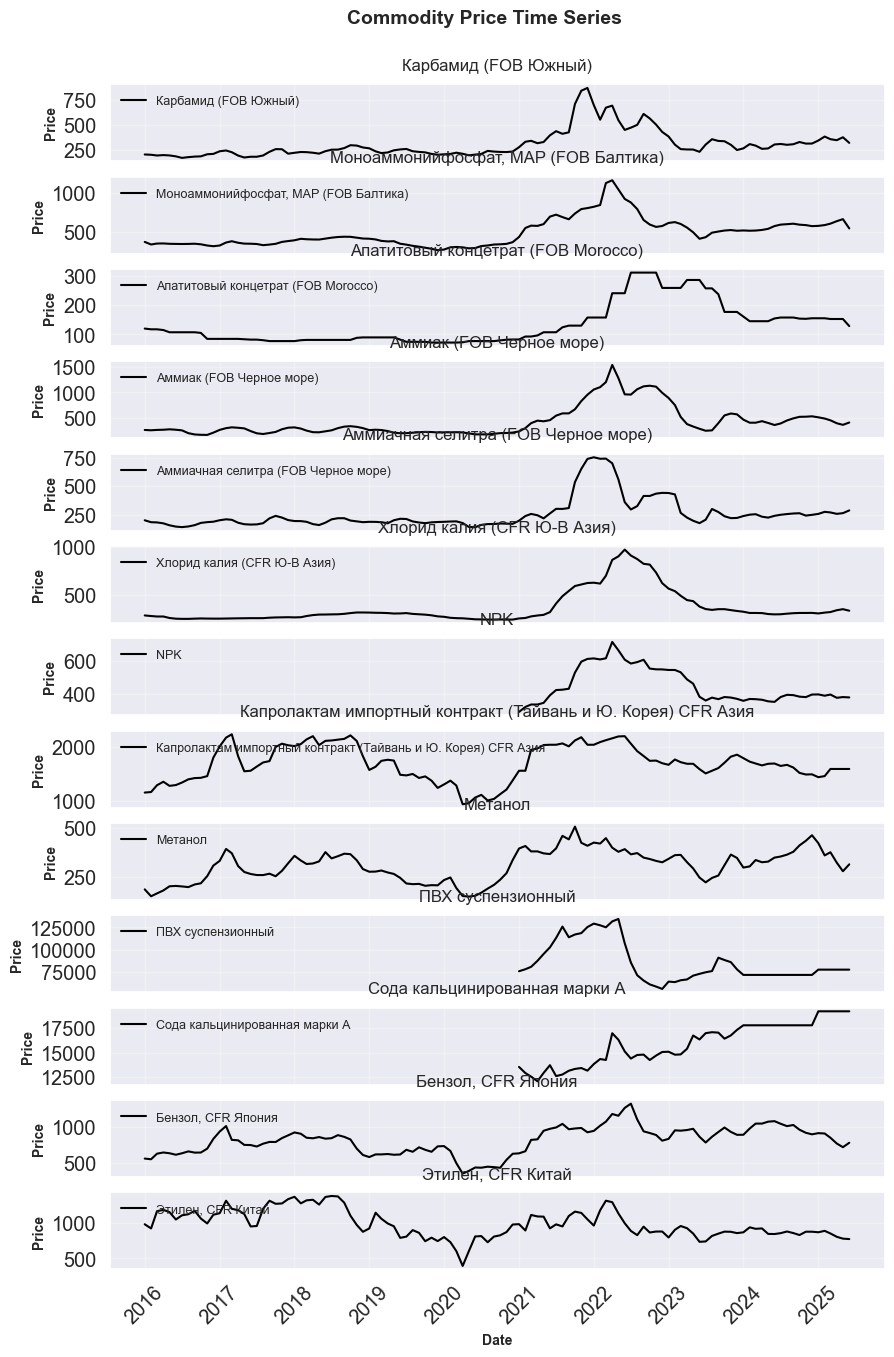

In [78]:
# TODO: add global macro features

df = pd.read_csv("/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/Data/chemicals.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'])
visualize_ts(df, df.columns, figsize=(10, 15))

df = df.drop(columns=['NPK', 'ПВХ суспензионный', 'Сода кальцинированная марки А'])

cluster_names_list = [df.columns[-4:], df.columns[:-4]]

# for cluster_names in cluster_names_list:
#     g = sns.PairGrid(df[cluster_names])
#     g.map_upper(sns.scatterplot)
#     g.map_lower(sns.kdeplot)
#     g.map_diag(sns.kdeplot, lw=3, legend=False)

# visualize_ts(df_log[cluster_names], cluster_names, figsize=(14, 30))

In [ ]:
from darts import TimeSeries as ts
from darts.metrics import mape

def fit_predict(model, training, validation, future_cov=[]):
    if len(future_cov) != 0:
        model.fit(training, future_covariates=future_cov)
        forecast = model.predict(n=len(validation), future_covariates=future_cov)
    else:
        model.fit(training)
        forecast = model.predict(len(validation))
    return forecast


def pipeline(model, data, holdout_time=24, cv=True, future_cov=[], plot=True):
    s = ts.from_dataframe(data)

    # split in train/validation sets
    holdout_time = holdout_time
    main_s, holdout_s = s[:-holdout_time], s[-holdout_time:]
    main_data, holdout_data = data.iloc[:-holdout_time], data.iloc[-holdout_time:]
    
    if cv: # crossvalidation
        cv = TimeSeriesSplit(n_splits = 2,
                            test_size=holdout_time
                            )

        mape_list  = []
        for train_index, test_index in cv.split(main_data):
            cv_train, cv_test = main_s[train_index[0]:train_index[-1]], main_s[test_index[0]:test_index[-1]]
            # print(f'Test length: {len(cv_test)}, Train lenght: {len(cv_train)}')
            
            preds = fit_predict(model, cv_train, cv_test, future_cov=future_cov)
            mape_list.append(mape(cv_test, preds))
        # print(f'MEAN MAPE: {round(np.mean(mape_list), 3)} %')
        # print(f'MAPE list: {list(np.round(mape_list, 2))} %')
    else:
        pass

    # train on all data
    preds = fit_predict(model, main_s, holdout_s, future_cov=future_cov)

    # plotting
    if plot:
        plt.figure(figsize=(10,4))
        s.plot(lw=3)
        preds.plot(lw=3, label='pred')
        plt.show()
    
    MAPE = mape(preds, holdout_s)
    # print(f'HOLDOUT MAPE: {round(MAPE, 2)} %')
    if cv:
        return np.mean(mape_list), MAPE
    else:
        return MAPE

In [ ]:
from darts.models import VARIMA, KalmanForecaster, LinearRegressionModel 
from darts.models import RandomForestModel, XGBModel, TCNModel, RNNModel 
from darts.models import TFTModel, NLinearModel, DLinearModel, TiDEModel, TSMixerModel

#говно
# RNNModel(input_chunk_length=6, 
#         model='GRU', 
#         hidden_dim=2, 
#         n_rnn_layers=1, 
#         dropout=0.2
#         )

# Говно
# model = TiDEModel(  
#     input_chunk_length=6,
#     output_chunk_length=6,
#     n_epochs=20,
#     hidden_size = 4, 
#     num_decoder_layers = 1,
#     num_encoder_layers = 1
# )


models_dict = dict(zip(
    ['VARIMA', 'KalmanForecaster', 'LinearRegressionModel', 'XGBModel', 'RandomForestModel', 'DLinearModel',  'TSMixerModel'], 
    [VARIMA(p = 1, d = 1, q = 0, trend=None),
     KalmanForecaster(dim_x=10),
     LinearRegressionModel(
        lags=[-1, -3, -6, -12], 
        likelihood='quantile',
        lags_future_covariates=[-1]
        ),s
     XGBModel(
        lags=[-1, -2, -4, -8, -16], 
        likelihood='quantile',
        lags_future_covariates=[-1]
        ),
     RandomForestModel(
        lags=[-1, -4, -12], 
        n_estimators=50, 
        max_depth=5,
        lags_future_covariates=[-1]
        ),
     DLinearModel(
        input_chunk_length=6,
        output_chunk_length=2,
        n_epochs=20,
        kernel_size=12,
        shared_weights=False,
        ),  
     TSMixerModel(
        input_chunk_length=6,
        output_chunk_length=6,
        use_reversible_instance_norm=True,
        n_epochs=20,
        )
]
))

_______________
VARIMA


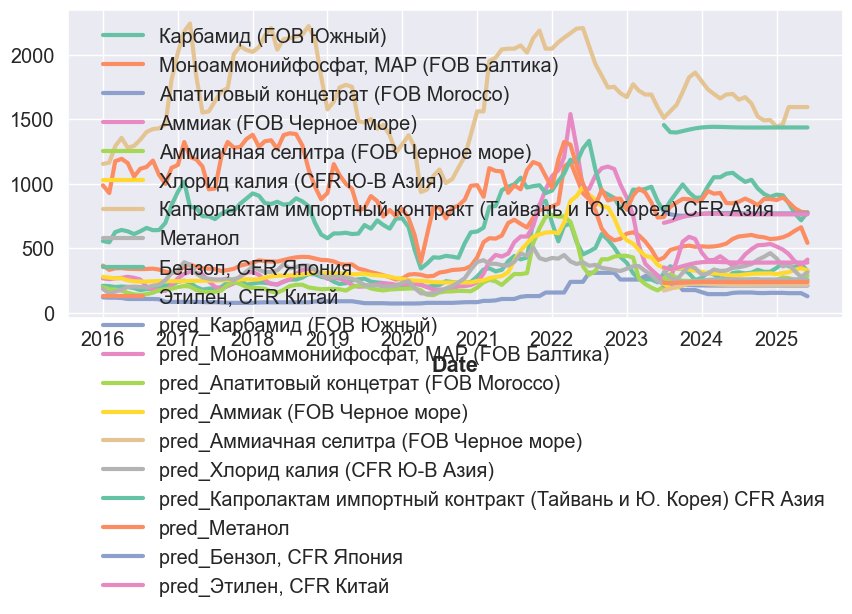

_______________
KalmanForecaster


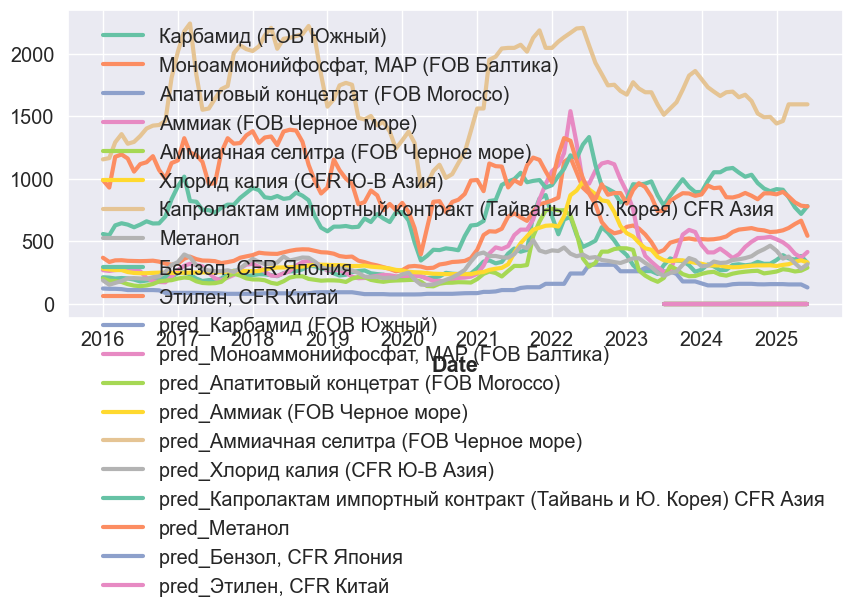

ValueError: `actual_series` must be strictly positive to compute the MAPE.


ValueError: `actual_series` must be strictly positive to compute the MAPE.

In [ ]:
mape_res_dict = {'Names': list(models_dict.keys()),
                #  'MeanCVMAPE': [], 
                 'HoldoutMAPE': []}

for name, model in models_dict.items():
    print('___'*5)
    print(name)
    holdout_mape = pipeline(model, 
            df,
            holdout_time=24,
            cv=False,
            # future_cov=[],
            future_cov=ts.from_series(df[cluster_names_list[0][1]]),
            plot=True
            )
    # mape_res_dict['MeanCVMAPE'].append(cv_mape)
    mape_res_dict['HoldoutMAPE'].append(holdout_mape)

pd.DataFrame(mape_res_dict)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# TODO: add normalization and staking
# TODO: add seasonal effects

#_____________without covariate
mape_res_dict = {'Names': list(models_dict.keys()),
                 'MeanCVMAPE': [], 
                 'HoldoutMAPE': []}

for name, model in models_dict.items():
    print('___'*5)
    print(name)
    cv_mape, holdout_mape = pipeline(model, 
            df[cluster_names_list[0]],
            holdout_time=24,
            cv=True,
            # future_cov=[],
            future_cov=ts.from_series(df[cluster_names_list[0][1]]),
            plot=False
            )
    mape_res_dict['MeanCVMAPE'].append(cv_mape)
    mape_res_dict['HoldoutMAPE'].append(holdout_mape)

pd.DataFrame(mape_res_dict)

_______________
VARIMA
_______________
KalmanForecaster
_______________
LinearRegressionModel
_______________
XGBModel


ValueError: The dimensionality of the series in the training set do not match the dimensionality of the series the model has previously been trained on. Model input/output dimensions = [10, None, 1, 1, None, 10], provided input/output dimensions = [4, None, 1, 1, None, 4]


_______________
RandomForestModel
_______________
DLinearModel


ValueError: The dimensionality of the series in the training set do not match the dimensionality of the series the model has previously been trained on. Model input/output dimensions = [10, None, 1, 1, None, 10], provided input/output dimensions = [4, None, 1, 1, None, 4]

In [ ]:
pd.DataFrame(mape_res_dict)

,Names,MeanCVMAPE,HoldoutMAPE
0,VARIMA,27.003682,26.000276
1,KalmanForecaster,15.743145,10.034276
2,LinearRegressionModel,32.525419,13.248648
3,XGBModel,26.714245,42.814839
4,RandomForestModel,26.818732,17.682639
5,DLinearModel,18.312551,12.373302
6,TSMixerModel,25.432677,7.971403


# Lets build matrix with covariates

In [ ]:
def matrix_pipeline(model, data, holdout_time=24, future_cov=[]):
    s = ts.from_dataframe(data)
    
    cv = TimeSeriesSplit(n_splits = 3,
                        test_size=holdout_time
                        )

    mape_dict  = dict(zip(list(df.columns), [[] for i in range(len(df.columns))]))
    for train_index, test_index in cv.split(data):
        cv_train, cv_test = s[train_index[0]:train_index[-1]], s[test_index[0]:test_index[-1]]
        preds = fit_predict(model, cv_train, cv_test, future_cov=future_cov)
        
        for i, name in enumerate(list(df.columns)):
            test_val = cv_test.values()[:, i]
            pred_val = preds.values()[:, i]
            mape_dict[name].append(mape(ts.from_values(test_val), ts.from_values(pred_val)))

    res_df = pd.DataFrame(mape_dict)
    return np.mean(res_df, axis=0)

pandas.core.series.Series

KalmanForecaster


100%|██████████| 10/10 [00:00<00:00, 19.72it/s]


Mean MAPE for horizon 12 = 29.43574935818111 %


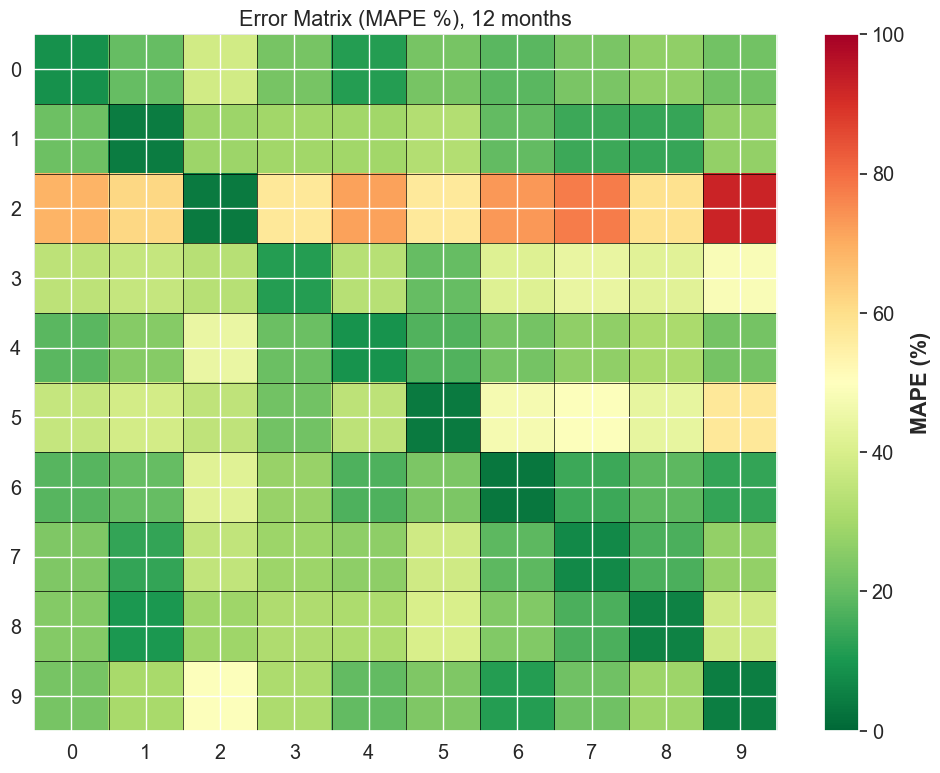

100%|██████████| 10/10 [00:00<00:00, 16.49it/s]


Mean MAPE for horizon 24 = 32.85445684519251 %


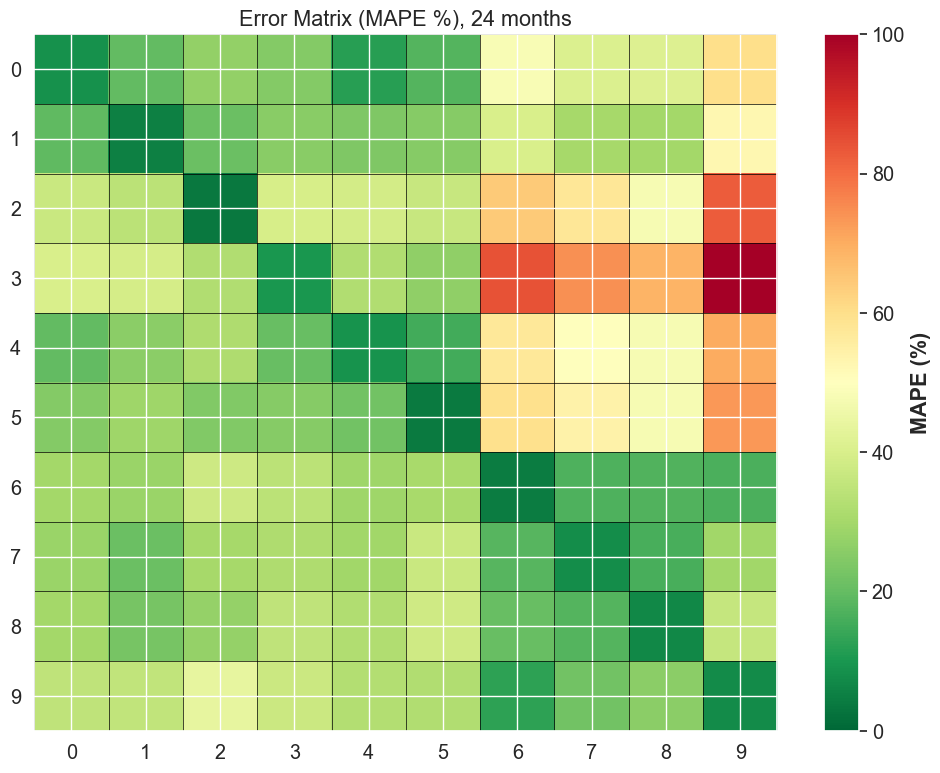

LinearRegressionModel


100%|██████████| 10/10 [00:10<00:00,  1.03s/it]

Mean MAPE for horizon 12 = 24.653703562359233 %


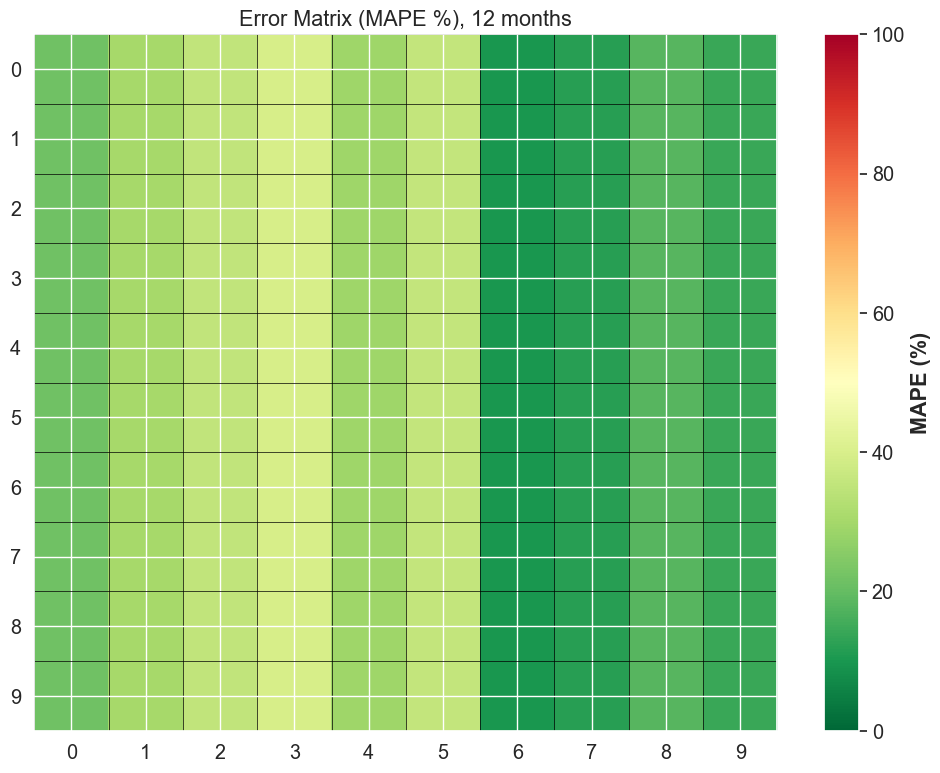

100%|██████████| 10/10 [00:09<00:00,  1.01it/s]

Mean MAPE for horizon 24 = 40.8886306165204 %


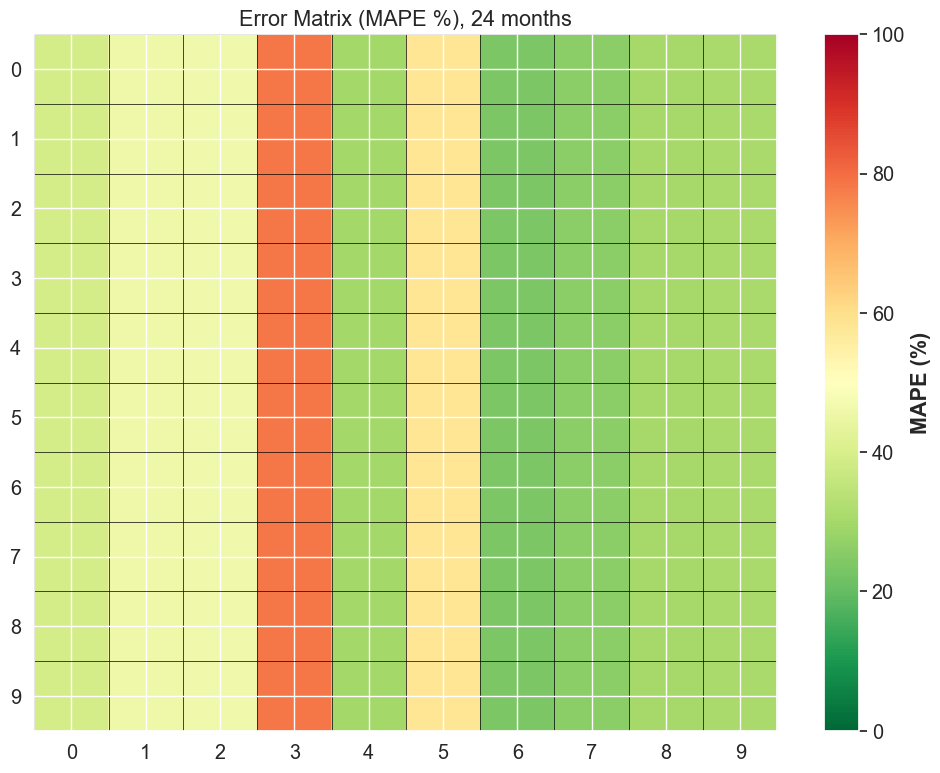

RandomForestModel


100%|██████████| 10/10 [00:01<00:00,  5.17it/s]


Mean MAPE for horizon 12 = 24.48924740971842 %


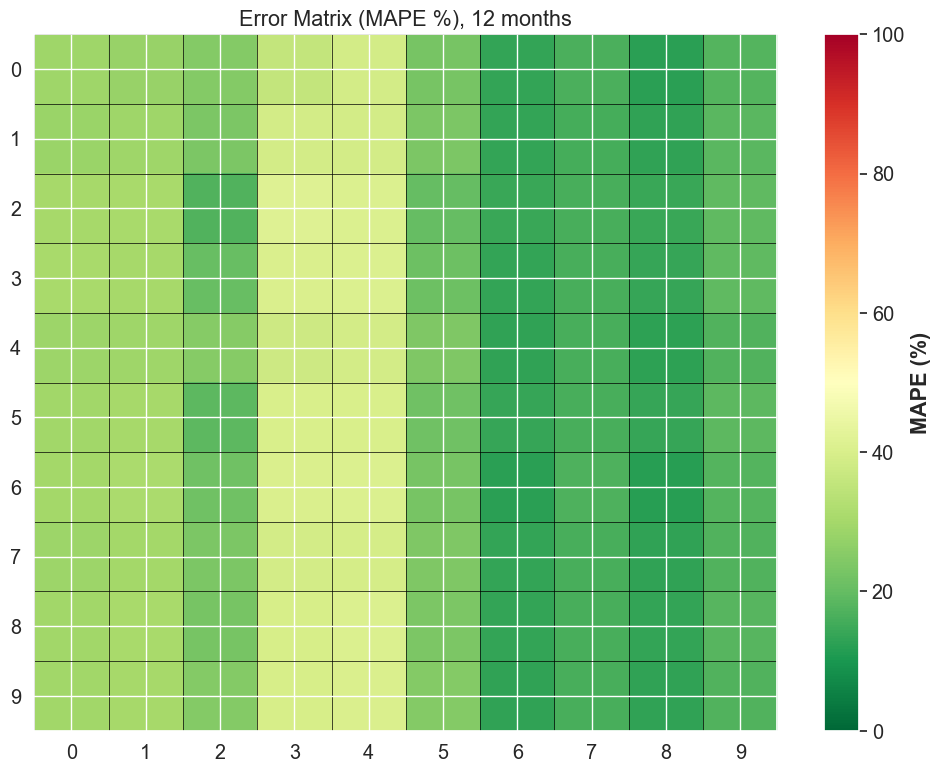

100%|██████████| 10/10 [00:01<00:00,  5.99it/s]


Mean MAPE for horizon 24 = 24.78411525166822 %


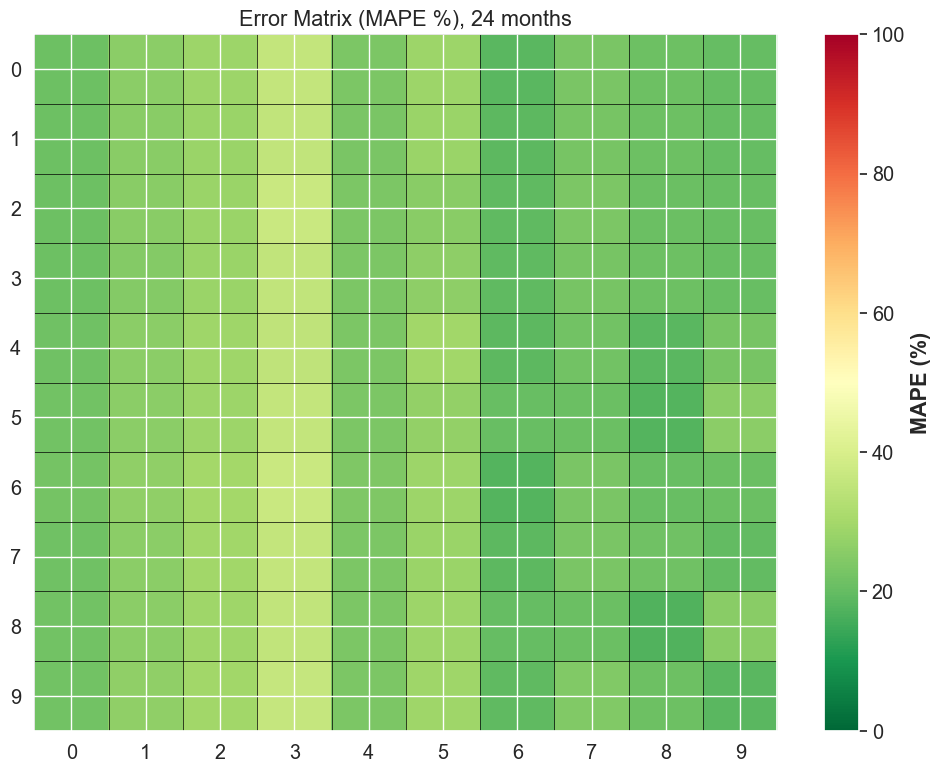

DLinearModel


  0%|          | 0/10 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 1.3 K  | train
7 | linear_trend    | Linear           | 1.3 K  | train
8 | linear_fut_cov  | Linear           | 20     | train
-------------------------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)
11        Modules in train mode
0   

Epoch 19: 100%|██████████| 3/3 [00:00<00:00, 343.67it/s, train_loss=2.49e+4]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 3/3 [00:00<00:00, 319.04it/s, train_loss=2.49e+4]

...

Epoch 19: 100%|██████████| 3/3 [00:00<00:00, 326.63it/s, train_loss=5.37e+3]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 339.21it/s]


100%|██████████| 10/10 [00:06<00:00,  1.54it/s]


Mean MAPE for horizon 12 = 32.11611650026855 %


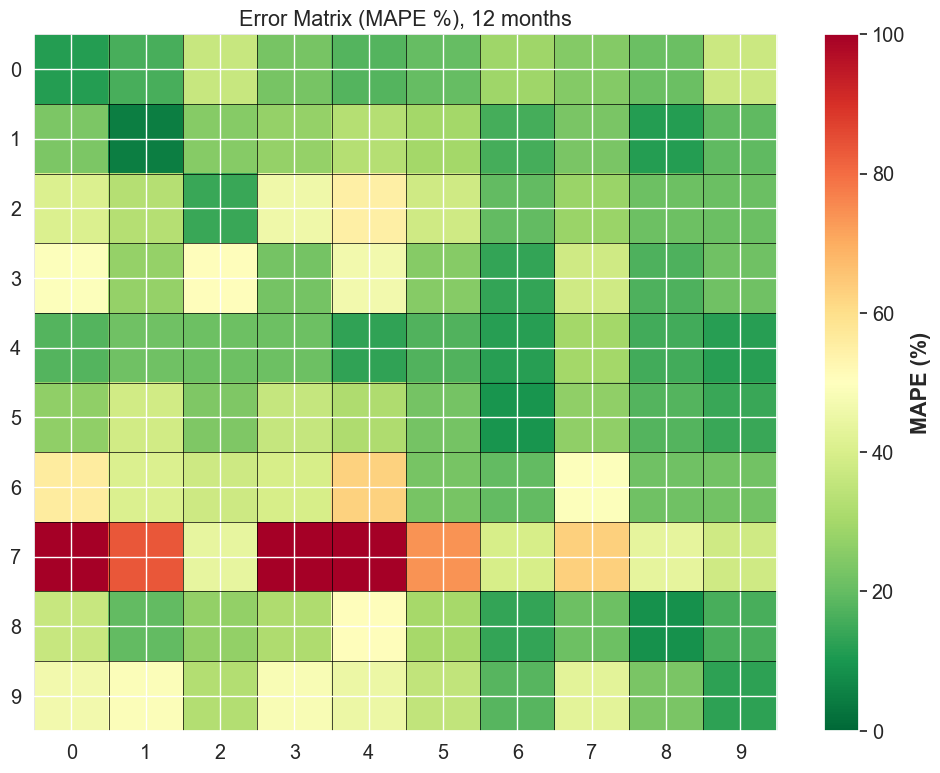

  0%|          | 0/10 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 1.3 K  | train
7 | linear_trend    | Linear           | 1.3 K  | train
8 | linear_fut_cov  | Linear           | 20     | train
-------------------------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)
11        Modules in train mode
0   

Epoch 19: 100%|██████████| 2/2 [00:00<00:00, 365.25it/s, train_loss=1.04e+4]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 2/2 [00:00<00:00, 333.50it/s, train_loss=1.04e+4]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Epoch 19: 100%|██████████| 3/3 [00:00<00:00, 391.99it/s, train_loss=3.03e+3]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 235.08it/s]


100%|██████████| 10/10 [00:05<00:00,  1.86it/s]

Mean MAPE for horizon 24 = 44.07257251553313 %


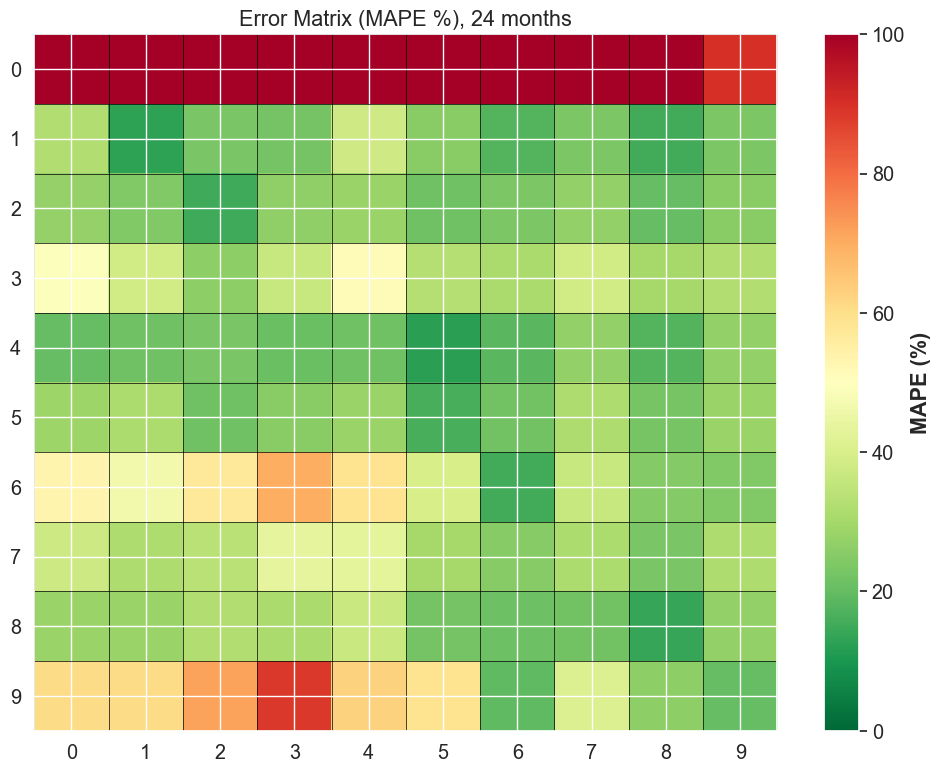

In [123]:
# for name, model in models_dict.items():
#     print('___'*5)
#     print(name)

models_dict = dict(zip(
    ['KalmanForecaster', 'LinearRegressionModel', 'RandomForestModel', 'DLinearModel'], 
    [KalmanForecaster(dim_x=10),
     LinearRegressionModel(
        lags=[-1], 
        likelihood='quantile',
        lags_future_covariates=[-1]
        ),
     RandomForestModel(
        lags=[-1, -4, -12], 
        n_estimators=50, 
        max_depth=5,
        lags_future_covariates=[-1]
        ),
     DLinearModel(
        input_chunk_length=6,
        output_chunk_length=2,
        n_epochs=20,
        kernel_size=12,
        shared_weights=False,
        ),
]
))
    
for model_name, model in models_dict.items():
    print('======'*5)
    print(model_name)
    for horizon in (12, 24):
        matrix_dict = {}
        for covariate_name in tqdm(list(df.columns)):
                mape_series = matrix_pipeline(model, 
                        df,
                        holdout_time=horizon,
                        future_cov=ts.from_series(df[covariate_name]),
                        )
                matrix_dict[covariate_name] = mape_series
                
        matrix_df = pd.DataFrame(matrix_dict).transpose()
        print(f'Mean MAPE for horizon {horizon} = {np.mean(matrix_df)} %')
        plot_error_matrix(matrix_df, title=f"Error Matrix (MAPE %), {horizon} months")